# Animation frames — detrended field, individual harmonics, and combined periodicities

Frame layout is copied from `crop_airs.ipynb` (spatial map on top, domain-mean timeseries with a red position dot at the bottom).

Five frame sets are produced, one folder each under `Figures/`:

| Folder | Field | Source file |
|---|---|---|
| `frames_detrended` | detrended CO anomaly | `detr_field.nc` |
| `frames_harmonic_12m` | 12-month (annual) harmonic | `harmonic_12m.nc` |
| `frames_harmonic_6m` | 6-month (semi-annual) harmonic | `harmonic_6m.nc` |
| `frames_harmonic_4m` | 4-month (terannual) harmonic | `harmonic_4m.nc` |
| `frames_periodicities` | combined 12+6+4 harmonics | `periodicities.nc` |

**One deviation from the source code:** these fields are anomalies centred on zero, not raw concentrations, so the map uses a diverging colormap (`RdBu_r`) symmetric about 0 instead of `YlOrRd` on the 2–98th percentile. The layout and timeseries panel are otherwise identical.

In [1]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import AutoMinorLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature

OUT_DIR = "../Figures"
os.makedirs(OUT_DIR, exist_ok=True)

# ── Load every field to be animated ──────────────────────────────────────────
detr_field = xr.open_dataarray("detr_field.nc")

fields = {
    "detrended":      detr_field,
    "harmonic_12m":   xr.open_dataset("harmonic_12m.nc")["harmonic_12m"],
    "harmonic_6m":    xr.open_dataset("harmonic_6m.nc")["harmonic_6m"],
    "harmonic_4m":    xr.open_dataset("harmonic_4m.nc")["harmonic_4m"],
    "periodicities":  xr.open_dataset("periodicities.nc")["periodicities"],
}

# Pretty titles used in the map panel heading
titles = {
    "detrended":     "AIRS CO mid-troposphere — detrended anomaly",
    "harmonic_12m":  "AIRS CO — 12-month (annual) harmonic",
    "harmonic_6m":   "AIRS CO — 6-month (semi-annual) harmonic",
    "harmonic_4m":   "AIRS CO — 4-month (terannual) harmonic",
    "periodicities": "AIRS CO — combined 12+6+4 month harmonics",
}

for name, da in fields.items():
    print(f"{name:15s} {str(dict(da.sizes)):45s} "
          f"min {float(da.min()):+.3e}  max {float(da.max()):+.3e}")

detrended       {'time': 276, 'lat': 36, 'lon': 61}           min -2.968e-08  max +6.810e-08
harmonic_12m    {'time': 276, 'lat': 36, 'lon': 61}           min -1.776e-08  max +1.776e-08
harmonic_6m     {'time': 276, 'lat': 36, 'lon': 61}           min -7.552e-09  max +7.552e-09
harmonic_4m     {'time': 276, 'lat': 36, 'lon': 61}           min -5.252e-09  max +5.252e-09
periodicities   {'time': 276, 'lat': 36, 'lon': 61}           min -1.732e-08  max +2.477e-08


In [ ]:
# ── Frame renderer: map (top) + timeseries with red dot (bottom) ─────────────
# Layout copied from crop_airs.ipynb "Generate HTML frames" cell.

def make_frame(i, date, co_map, ctx):
    """Render one frame and return the figure.

    ctx carries everything that is constant across the frames of one field:
    lons, lats, extent, colour limits, timeseries arrays and y-limits.
    """
    fig_f = plt.figure(figsize=(9, 7.2), facecolor="white")
    gs_f  = fig_f.add_gridspec(
        2, 1,
        height_ratios=[1.55, 1.0],
        hspace=0.42,
        left=0.10, right=0.88,
        top=0.93,  bottom=0.08,
    )

    # -- top: spatial map --------------------------------------------------
    ax_map_f = fig_f.add_subplot(gs_f[0], projection=ccrs.PlateCarree())
    ax_map_f.set_extent([ctx["lon_min"], ctx["lon_max"],
                         ctx["lat_min"], ctx["lat_max"]],
                        crs=ccrs.PlateCarree())
    ax_map_f.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="k")
    ax_map_f.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor="#555")
    ax_map_f.add_feature(cfeature.STATES,    linewidth=0.25, edgecolor="#888")

    pcm_f = ax_map_f.pcolormesh(
        ctx["lons"], ctx["lats"], co_map,
        transform=ccrs.PlateCarree(),
        cmap=ctx["cmap"], vmin=ctx["vmin"], vmax=ctx["vmax"],
        shading="nearest",
    )
    gl_f = ax_map_f.gridlines(draw_labels=True, linewidth=0, color="none")
    gl_f.top_labels   = False
    gl_f.right_labels = False

    cb_f = fig_f.colorbar(pcm_f, ax=ax_map_f, orientation="vertical",
                          fraction=0.03, pad=0.06)
    cb_f.set_label("Values  (kg kg⁻¹)", fontsize=8)
    ax_map_f.set_title(
        f"{ctx['title']}  |  {date.strftime('%B %Y')}",
        fontsize=10, pad=4,
    )

    # -- bottom: timeseries + red dot --------------------------------------
    ts_dates = ctx["ts_dates"]
    ts_co    = ctx["ts_co"]

    ax_ts_f = fig_f.add_subplot(gs_f[1])
    ax_ts_f.plot(ts_dates, ts_co, lw=1.2, color="#d35400", zorder=3)
    ax_ts_f.fill_between(ts_dates, ts_co, ctx["ts_ymin"] - ctx["ts_pad"],
                         alpha=0.35, color="#f9e79f", zorder=2)

    # The 12-month rolling mean of a pure harmonic is a flat zero line, so it is
    # only drawn where it actually carries information (the detrended field).
    if ctx["roll_co"] is not None:
        ax_ts_f.plot(ts_dates, ctx["roll_co"], lw=1.8, color="k", alpha=0.4,
                     linestyle="--", zorder=4)

    ax_ts_f.axhline(0, color="k", lw=0.6, alpha=0.5, zorder=1)
    ax_ts_f.plot(date, ts_co[i], "o", color="red", ms=6, zorder=5)

    ax_ts_f.set_xlim(ts_dates[0], ts_dates[-1])
    ax_ts_f.set_ylim(ctx["ts_ymin"] - ctx["ts_pad"], ctx["ts_ymax"] + ctx["ts_pad"])
    ax_ts_f.set_ylabel("Values  (kg kg⁻¹)", fontsize=8)
    ax_ts_f.xaxis.set_major_locator(mdates.YearLocator(2))
    ax_ts_f.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax_ts_f.xaxis.set_minor_locator(mdates.YearLocator())
    ax_ts_f.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax_ts_f.grid(axis="y", which="major", lw=0.4, alpha=0.5)
    ax_ts_f.grid(axis="y", which="minor", lw=0.15, alpha=0.25)
    ax_ts_f.grid(axis="x", which="minor", lw=0.15, alpha=0.2)
    ax_ts_f.tick_params(labelsize=7)

    # -- align map centre to timeseries centre -----------------------------
    # Draw first so matplotlib computes the actual axis positions
    fig_f.canvas.draw()

    pos_ts  = ax_ts_f.get_position()    # timeseries bounding box (fig coords)
    pos_map = ax_map_f.get_position()   # map bounding box (fig coords)

    ts_cx  = pos_ts.x0  + pos_ts.width  / 2   # centre-x of timeseries
    map_hw = pos_map.width / 2                 # half-width of map

    # Shift map horizontally so its centre matches the timeseries centre
    ax_map_f.set_position([
        ts_cx - map_hw,     # new x0
        pos_map.y0,         # keep vertical position
        pos_map.width,      # keep width
        pos_map.height,     # keep height
    ])

    return fig_f


def build_ctx(name, da):
    """Assemble the per-field constants used by make_frame."""
    lons  = da.lon.values
    lats  = da.lat.values
    dates = pd.DatetimeIndex(da.time.values)

    # Domain-mean timeseries (as in crop_airs.ipynb)
    ts_co = da.mean(("lat", "lon")).values

    roll_co = None

    # Anomaly fields straddle zero -> symmetric diverging scale about 0.
    lim = float(np.nanpercentile(np.abs(da.values), 99))

    ts_ymin = float(np.nanmin(ts_co))
    ts_ymax = float(np.nanmax(ts_co))

    return {
        "lons": lons, "lats": lats,
        "lon_min": float(lons.min()), "lon_max": float(lons.max()),
        "lat_min": float(lats.min()), "lat_max": float(lats.max()),
        "cmap": plt.cm.RdBu_r, "vmin": -lim, "vmax": lim,
        "ts_dates": dates, "ts_co": ts_co, "roll_co": roll_co,
        "ts_ymin": ts_ymin, "ts_ymax": ts_ymax,
        "ts_pad": (ts_ymax - ts_ymin) * 0.06,
        "title": titles[name],
    }

print("make_frame / build_ctx defined.")

make_frame / build_ctx defined.


field       : periodicities
frame       : July 2003  (index 6 of 276)
colour range: ±1.934e-08 kg/kg
filename    : 200307.png  ->  Figures/frames_periodicities/


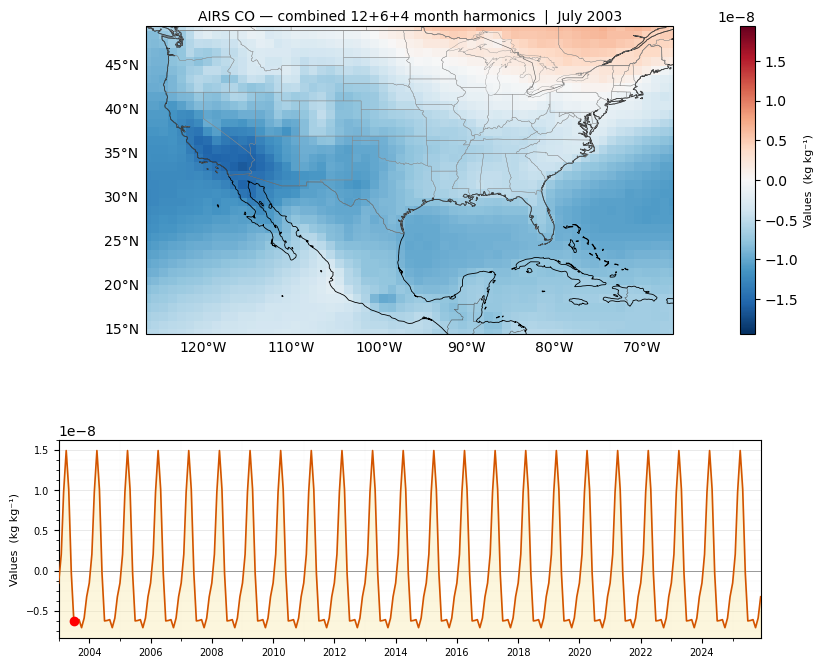

In [8]:
# ── TEST: render a single frame to check the layout ──────────────────────────
# Nothing is saved here. Change TEST_FIELD / TEST_MONTH and re-run until the
# frame looks right, then run the cells below to generate the full sets.

TEST_FIELD = "periodicities"   # detrended | harmonic_12m | harmonic_6m | harmonic_4m | periodicities
TEST_MONTH = "2003-07"         # any month from 2003-01 to 2025-12

da_t  = fields[TEST_FIELD]
ctx_t = build_ctx(TEST_FIELD, da_t)

# Locate the requested month in the time axis
i_t    = int(ctx_t["ts_dates"].get_loc(pd.Timestamp(TEST_MONTH + "-01")))
date_t = ctx_t["ts_dates"][i_t]

print(f"field       : {TEST_FIELD}")
print(f"frame       : {date_t.strftime('%B %Y')}  (index {i_t} of {len(ctx_t['ts_dates'])})")
print(f"colour range: ±{ctx_t['vmax']:.3e} kg/kg")
print(f"filename    : {date_t.strftime('%Y%m')}.png  ->  Figures/frames_{TEST_FIELD}/")

fig_t = make_frame(i_t, date_t, da_t.isel(time=i_t).values, ctx_t)
plt.show()

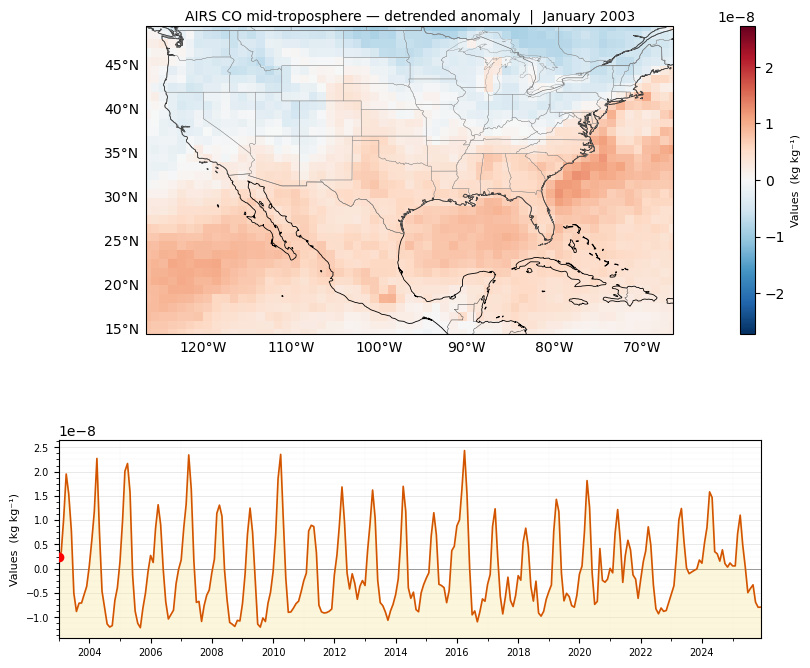

detrended: colour limits ±2.717e-08 kg/kg, 276 frames to generate



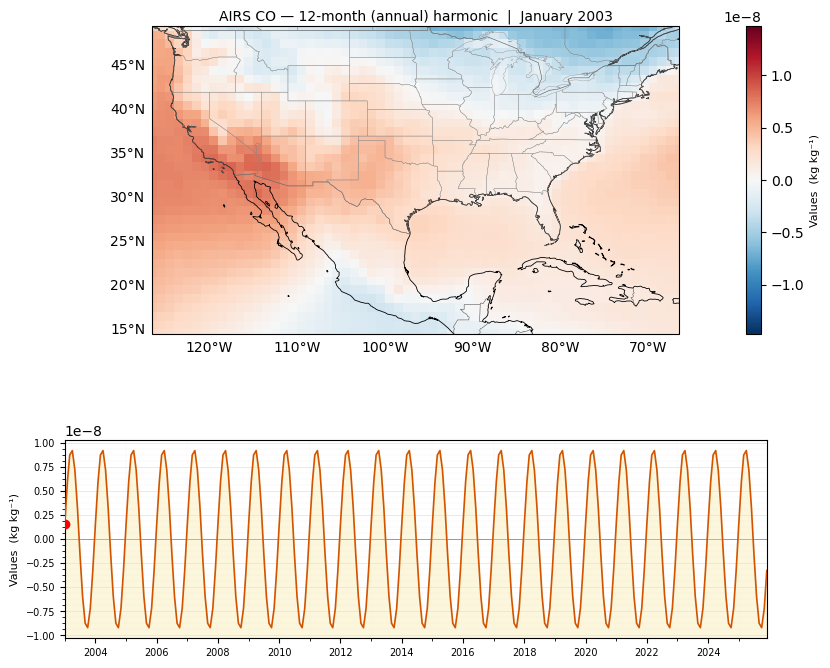

harmonic_12m: colour limits ±1.469e-08 kg/kg, 276 frames to generate



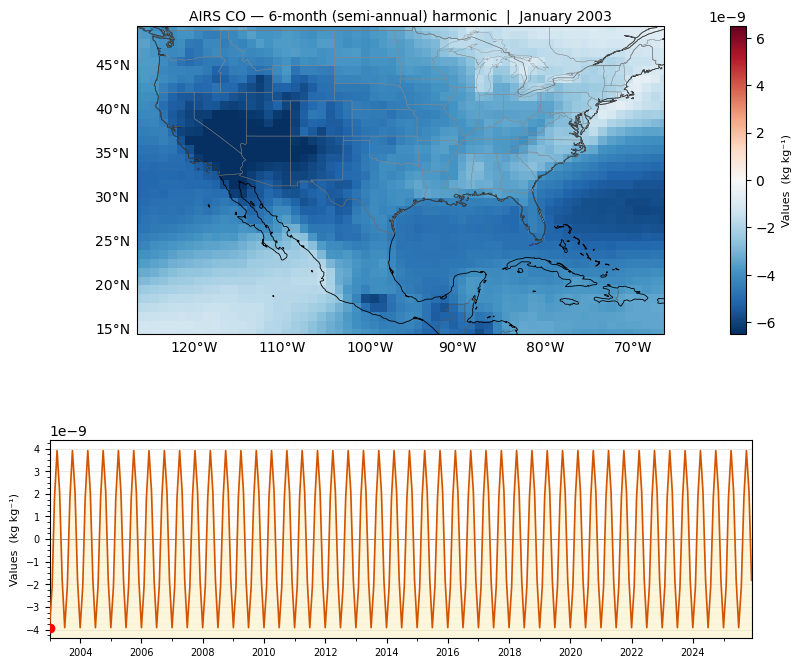

harmonic_6m: colour limits ±6.483e-09 kg/kg, 276 frames to generate



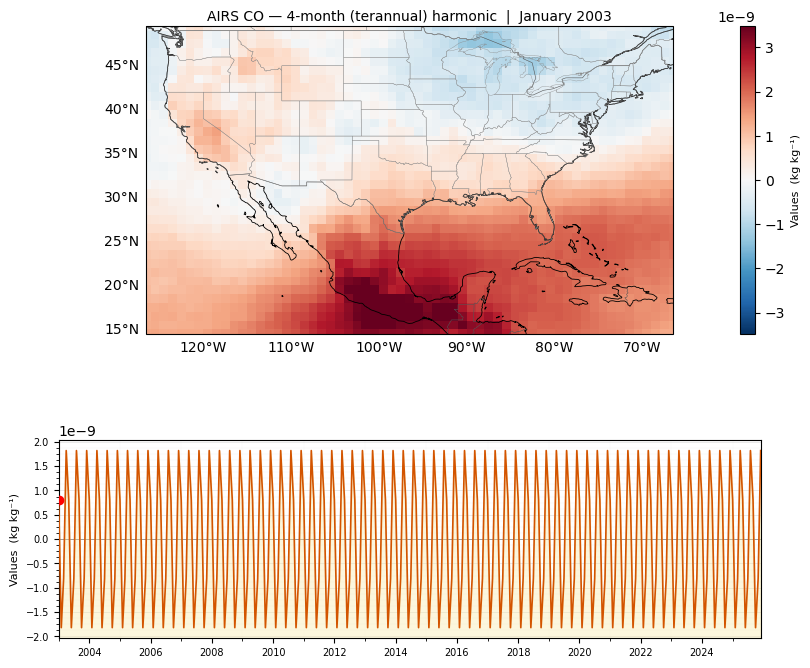

harmonic_4m: colour limits ±3.480e-09 kg/kg, 276 frames to generate



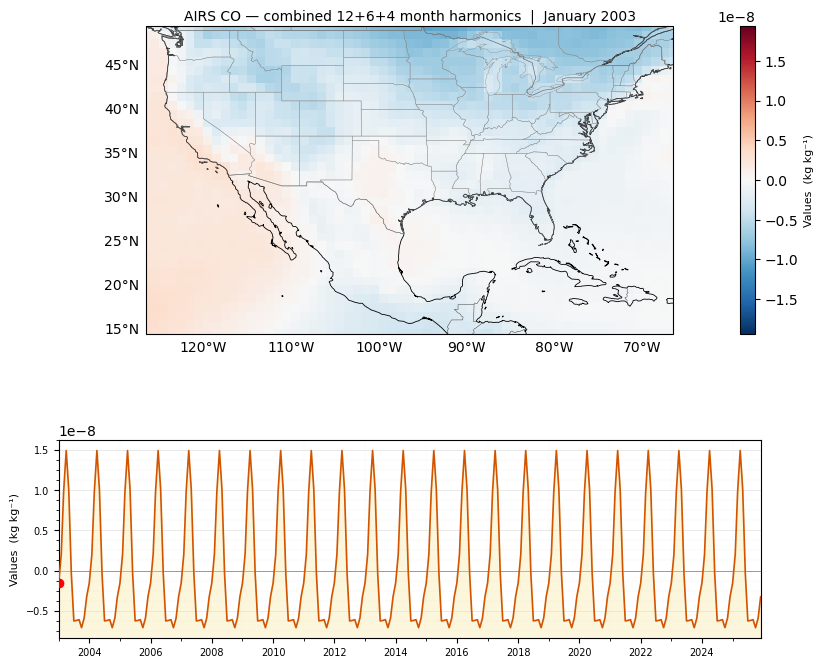

periodicities: colour limits ±1.934e-08 kg/kg, 276 frames to generate



In [9]:
# ── Preview one frame per field before generating the full sets ──────────────
# (crop_airs.ipynb asked for y/n via input(); here the preview is just shown,
#  so a "Run All" does not block waiting on stdin.)

for name, da in fields.items():
    ctx = build_ctx(name, da)
    fig_p = make_frame(0, ctx["ts_dates"][0], da.isel(time=0).values, ctx)
    plt.show()
    plt.close(fig_p)
    print(f"{name}: colour limits ±{ctx['vmax']:.3e} kg/kg, "
          f"{len(ctx['ts_dates'])} frames to generate\n")

In [10]:
# ── Generate all frame sets ──────────────────────────────────────────────────
# Output: Figures/frames_<field>/<YYYYMM>.png   e.g. 200301.png, 200302.png
# 5 fields x 276 months = 1380 frames; expect this to take a while.

import matplotlib
matplotlib.use("Agg")            # no on-screen rendering -> much faster

frame_dirs = {}

for name, da in fields.items():
    ctx  = build_ctx(name, da)
    fdir = os.path.join(OUT_DIR, f"frames_{name}")
    os.makedirs(fdir, exist_ok=True)
    frame_dirs[name] = fdir

    values = da.values                      # pull into memory once
    dates  = ctx["ts_dates"]
    n      = len(dates)

    print(f"\nGenerating {n} frames -> {fdir}")
    for i, date in enumerate(dates):
        fname = date.strftime("%Y%m") + ".png"
        fig_f = make_frame(i, date, values[i], ctx)
        fig_f.savefig(
            os.path.join(fdir, fname),
            dpi=120, bbox_inches="tight", facecolor="white",
        )
        plt.close(fig_f)
        if (i + 1) % 50 == 0 or i == n - 1:
            print(f"  {i + 1}/{n}  -> {fname}")

matplotlib.use("module://matplotlib_inline.backend_inline")   # restore inline plots

print("\nDone. Frame folders:")
for name, d in frame_dirs.items():
    print(f"  {name:15s} {len(os.listdir(d)):4d} frames  in  {d}")


Generating 276 frames -> ../Figures\frames_detrended
  50/276  -> 200702.png
  100/276  -> 201104.png
  150/276  -> 201506.png
  200/276  -> 201908.png
  250/276  -> 202310.png
  276/276  -> 202512.png

Generating 276 frames -> ../Figures\frames_harmonic_12m
  50/276  -> 200702.png
  100/276  -> 201104.png
  150/276  -> 201506.png
  200/276  -> 201908.png
  250/276  -> 202310.png
  276/276  -> 202512.png

Generating 276 frames -> ../Figures\frames_harmonic_6m
  50/276  -> 200702.png
  100/276  -> 201104.png
  150/276  -> 201506.png
  200/276  -> 201908.png
  250/276  -> 202310.png
  276/276  -> 202512.png

Generating 276 frames -> ../Figures\frames_harmonic_4m
  50/276  -> 200702.png
  100/276  -> 201104.png
  150/276  -> 201506.png
  200/276  -> 201908.png
  250/276  -> 202310.png
  276/276  -> 202512.png

Generating 276 frames -> ../Figures\frames_periodicities
  50/276  -> 200702.png
  100/276  -> 201104.png
  150/276  -> 201506.png
  200/276  -> 201908.png
  250/276  -> 202310.png